In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df_application = pd.read_csv('application_record.csv')
df_credit = pd.read_csv('credit_record.csv')

df_application.shape

(438557, 18)

In [29]:
df_credit.shape

(1048575, 3)

In [30]:
df_application.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [31]:
print(f"Shape               : {df_application.shape}")
print(f"Number of Features  : {df_application.shape[1]}")
print(f"Number of Records   : {df_application.shape[0]}")
print(f"Duplicate Records   : {df_application.duplicated().sum()}")
print(f"Unique Customer IDs : {df_application['ID'].nunique()}")

Shape               : (438557, 18)
Number of Features  : 18
Number of Records   : 438557
Duplicate Records   : 0
Unique Customer IDs : 438510


In [32]:
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [33]:
print("\nMissing Values")
display(
    df_credit.isnull().sum()
    .to_frame("Missing Values")
    .query("`Missing Values` > 0")
)

print("\nData Types")
display(df_credit.dtypes.to_frame("Data Type"))


Missing Values


,Missing Values



Data Types


,Data Type
ID,int64
MONTHS_BALANCE,int64
STATUS,str


In [34]:
# Generate descriptive statistics for all numerical columns and transpose
# the result so each feature appears as a separate row, .T transposes the table to make it easier to read.
display(df_credit.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,1048575.0,5.068286e+06,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,-1.913700e+01,14.023498,-60.0,-29.0,-17.0,-7.0,0.0


In [35]:
print("\nSTATUS Distribution")
display(df_credit["STATUS"].value_counts().to_frame("Count"))

# Count how many times each unique value appears in the STATUS column and convert the result into a DataFrame with a "Count" column.


STATUS Distribution


,Count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [36]:
print("\nSTATUS Distribution (%)")
display(
    (
        df_credit["STATUS"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    ).to_frame("Percentage")
)


STATUS Distribution (%)


,Percentage
STATUS,
C,42.16
0,36.54
X,19.95
1,1.06
5,0.16
2,0.08
3,0.03
4,0.02


In [37]:
application_ids = set(df_application["ID"])
credit_ids = set(df_credit["ID"])

common_ids = application_ids.intersection(credit_ids)

print(f"Customers in Application Dataset : {len(application_ids):,}")
print(f"Customers in Credit Dataset      : {len(credit_ids):,}")
print(f"Common Customers                 : {len(common_ids):,}")
print(f"IDs only in Application Dataset  : {len(application_ids - credit_ids):,}")
print(f"IDs only in Credit Dataset       : {len(credit_ids - application_ids):,}")

Customers in Application Dataset : 438,510
Customers in Credit Dataset      : 45,985
Common Customers                 : 36,457
IDs only in Application Dataset  : 402,053
IDs only in Credit Dataset       : 9,528


In [38]:
print(df_credit["STATUS"].value_counts().sort_index())

STATUS
0    383120
1     11090
2       868
3       320
4       223
5      1693
C    442031
X    209230
Name: count, dtype: int64


In [39]:
# Define the STATUS values that represent a bad/late credit payment.
bad_status = ["2", "3", "4", "5"]

# Create a binary TARGET column:
# 1 if the customer has a bad status, otherwise 0.
df_credit["TARGET"] = df_credit["STATUS"].isin(bad_status).astype(int)

# Group records by customer ID and take the maximum TARGET value.
# This marks a customer as 1 if they had at least one bad status.
target_df = (
    df_credit
    .groupby("ID")["TARGET"]
    .max()
    .reset_index()
)

# Display the number of customers in each target class.
print(target_df["TARGET"].value_counts())

TARGET
0    45318
1      667
Name: count, dtype: int64


In [40]:
# Merge the application data with the target labels using the customer ID.
# An inner join keeps only customers that exist in both DataFrames.
df = df_application.merge(
    target_df,
    on="ID",
    how="inner"
)

print(f"Shape               : {df.shape}")
print(f"Number of Features  : {df.shape[1]}")
print(f"Duplicate Records   : {df.duplicated().sum()}")

print("\nTarget Distribution")
print(df["TARGET"].value_counts())

print(f"\nDataset Shape       : {df.shape}")
print(f"Duplicate Rows      : {df.duplicated().sum()}")

Shape               : (36457, 19)
Number of Features  : 19
Duplicate Records   : 0

Target Distribution
TARGET
0    35841
1      616
Name: count, dtype: int64

Dataset Shape       : (36457, 19)
Duplicate Rows      : 0


In [41]:
# Count missing values in each column.
missing = df.isnull().sum()

# Keep only columns that contain missing values and sort them
# from the highest number of missing values to the lowest.
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing Values")

# Check whether any columns contain missing values.
if len(missing) == 0:

    print("No Missing Values Found.")

else:

    # Display the missing-value counts in a readable DataFrame.
    display(missing.to_frame(name="Missing Values"))


# Count the number of unique customers based on their IDs.
print(f"\nUnique Customer IDs : {df['ID'].nunique()}")

print("\nDAYS_EMPLOYED Value Counts (Top 10)")
display(df["DAYS_EMPLOYED"].value_counts().head(10))


Missing Values


,Missing Values
OCCUPATION_TYPE,11323



Unique Customer IDs : 36457

DAYS_EMPLOYED Value Counts (Top 10)


DAYS_EMPLOYED
 365243    6135
-401         78
-1539        64
-200         63
-1678        61
-2087        61
-2531        56
-460         54
-1160        53
-1661        52
Name: count, dtype: int64

In [42]:
print(f"Dataset Shape      : {df.shape}")
print(f"Number of Features : {df.shape[1]}")
print(f"Duplicate Rows     : {df.duplicated().sum()}")

Dataset Shape      : (36457, 19)
Number of Features : 19
Duplicate Rows     : 0


In [43]:
display(df["TARGET"].value_counts().to_frame(name="Count"))

display(
    (
        df["TARGET"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    ).to_frame(name="Percentage")
)

,Count
TARGET,
0,35841
1,616


,Percentage
TARGET,
0,98.31
1,1.69


In [44]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5.078227e+06,41875.240788,5008804.0,5042028.0,5074614.0,5115396.0,5150487.0
CNT_CHILDREN,36457.0,4.303152e-01,0.742367,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,36457.0,1.866857e+05,101789.226482,27000.0,121500.0,157500.0,225000.0,1575000.0
DAYS_BIRTH,36457.0,-1.597517e+04,4200.549944,-25152.0,-19438.0,-15563.0,-12462.0,-7489.0
DAYS_EMPLOYED,36457.0,5.926294e+04,137651.334859,-15713.0,-3153.0,-1552.0,-408.0,365243.0
FLAG_MOBIL,36457.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,36457.0,2.255260e-01,0.417934,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,36457.0,2.948131e-01,0.455965,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,36457.0,8.972214e-02,0.285787,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,36457.0,2.198453e+00,0.911686,1.0,2.0,2.0,3.0,20.0


In [45]:
display(df.describe(include="object").T)

C:\Users\piyus\AppData\Local\Temp\ipykernel_19732\2515387694.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
CODE_GENDER,36457,2,F,24430
FLAG_OWN_CAR,36457,2,N,22614
FLAG_OWN_REALTY,36457,2,Y,24506
NAME_INCOME_TYPE,36457,5,Working,18819
NAME_EDUCATION_TYPE,36457,5,Secondary / secondary special,24777
NAME_FAMILY_STATUS,36457,5,Married,25048
NAME_HOUSING_TYPE,36457,6,House / apartment,32548
OCCUPATION_TYPE,25134,18,Laborers,6211


C:\Users\piyus\AppData\Local\Temp\ipykernel_19732\1604062759.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


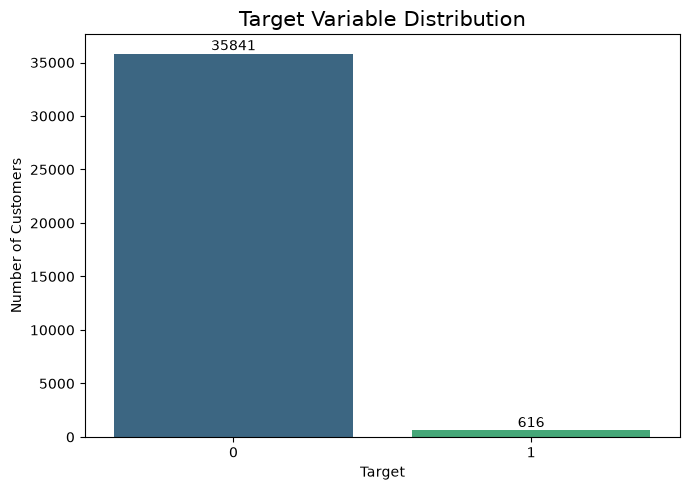

In [46]:
plt.figure(figsize=(7, 5))

# Count Plot
ax = sns.countplot(
    data=df,
    x="TARGET",
    palette="viridis"
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Title & Labels
plt.title("Target Variable Distribution", fontsize=15)
plt.xlabel("Target")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [47]:
target_percentage = (
    df["TARGET"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("=" * 45)
print("Target Distribution (%)")
print("=" * 45)

display(target_percentage.to_frame(name="Percentage"))

Target Distribution (%)


,Percentage
TARGET,
0,98.31
1,1.69


In [48]:
df_clean = df.copy()

# Replace the placeholder value 365243 in DAYS_EMPLOYED with NaN
# because it represents an invalid/missing employment value.
df_clean["DAYS_EMPLOYED"] = (
    df_clean["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
)

# Replace missing occupation values with "Unknown" so that
# missing categorical values are handled without removing rows.
df_clean["OCCUPATION_TYPE"] = (
    df_clean["OCCUPATION_TYPE"]
    .fillna("Unknown")
)

# Display the number of rows and columns after cleaning.
print(f"Dataset Shape : {df_clean.shape}")

print("\nRemaining Missing Values")

# Count missing values in each column.
remaining_missing = (
    df_clean
    .isnull()
    .sum()
)

# Keep only columns that still contain missing values.
remaining_missing = remaining_missing[
    remaining_missing > 0
]

# Check whether any missing values are still present.
if remaining_missing.empty:

    print("No Missing Values Remaining.")

else:

    # Display the remaining missing-value counts.
    display(
        remaining_missing.to_frame(
            name="Missing Values"
        )
    )

# Count completely duplicated rows in the cleaned dataset.
print("\nDuplicate Rows :", df_clean.duplicated().sum())

Dataset Shape : (36457, 19)

Remaining Missing Values


,Missing Values
DAYS_EMPLOYED,6135



Duplicate Rows : 0


In [49]:
# DAYS_BIRTH contains a person's age in days as a negative value.
# For example, -10000 means the person has lived for 10,000 days.
# Negating the value makes it positive, then dividing by 365 converts
# the age from days to years. astype(int) removes the decimal part.
df_clean["AGE"] = (
    (-df_clean["DAYS_BIRTH"]) / 365
).astype(int)

# DAYS_EMPLOYED stores employment duration as a negative number of days.
# Negating it converts the duration to positive days, and dividing by
# 365 converts the duration from days into approximately years.
df_clean["YEARS_EMPLOYED"] = (
    (-df_clean["DAYS_EMPLOYED"]) / 365
)

# Convert any remaining negative employment durations to positive values.
# abs() changes values such as -5.2 to 5.2 while leaving positive values unchanged.
df_clean["YEARS_EMPLOYED"] = (
    df_clean["YEARS_EMPLOYED"]
    .abs()
)

# Select the original day-based columns along with the newly created
# AGE and YEARS_EMPLOYED features and display the first 5 rows.
# This lets us verify that the feature engineering calculations worked correctly.
display(
    df_clean[
        [
            "DAYS_BIRTH",
            "AGE",
            "DAYS_EMPLOYED",
            "YEARS_EMPLOYED"
        ]
    ].head()
)

,DAYS_BIRTH,AGE,DAYS_EMPLOYED,YEARS_EMPLOYED
0,-12005,32,-4542.0,12.443836
1,-12005,32,-4542.0,12.443836
2,-21474,58,-1134.0,3.106849
3,-19110,52,-3051.0,8.358904
4,-19110,52,-3051.0,8.358904


In [50]:
df_clean.drop(
    columns=[
        "DAYS_BIRTH",
        "DAYS_EMPLOYED"
    ],
    inplace=True
)


print(f"Dataset Shape : {df_clean.shape}")

print("\nCurrent Features")

display(df_clean.head())

Dataset Shape : (36457, 19)

Current Features


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,0,32,12.443836
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,0,32,12.443836
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58,3.106849
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8.358904
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8.358904


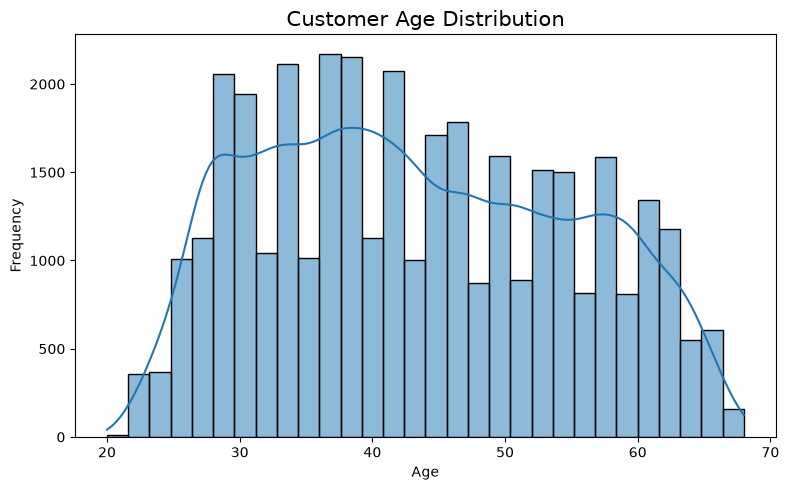

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="AGE",
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution", fontsize=15)
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()

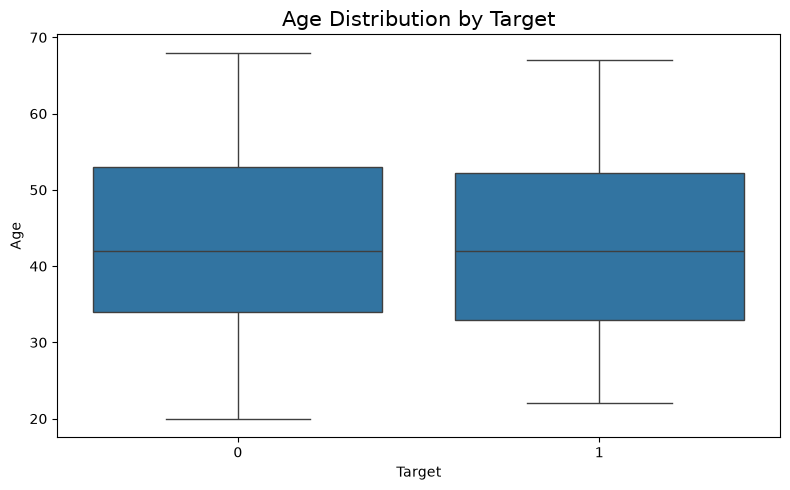

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="TARGET",
    y="AGE"
)

plt.title("Age Distribution by Target", fontsize=15)
plt.xlabel("Target")
plt.ylabel("Age")

plt.tight_layout()

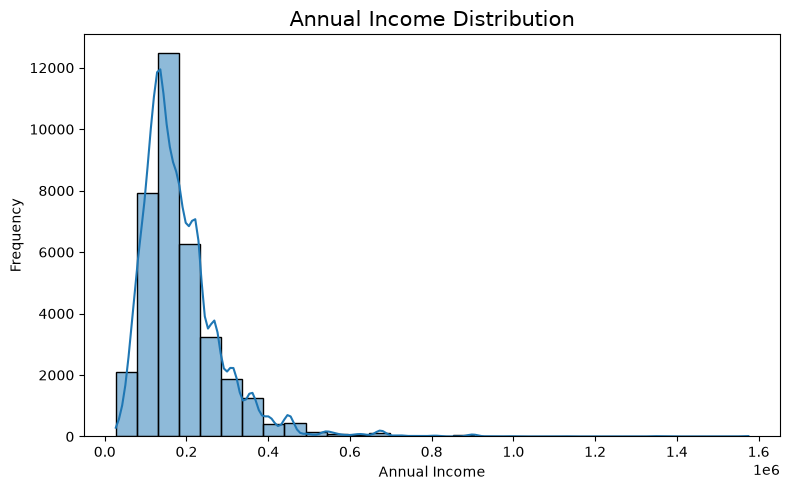

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="AMT_INCOME_TOTAL",
    bins=30,
    kde=True
)

plt.title("Annual Income Distribution", fontsize=15)
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.tight_layout()

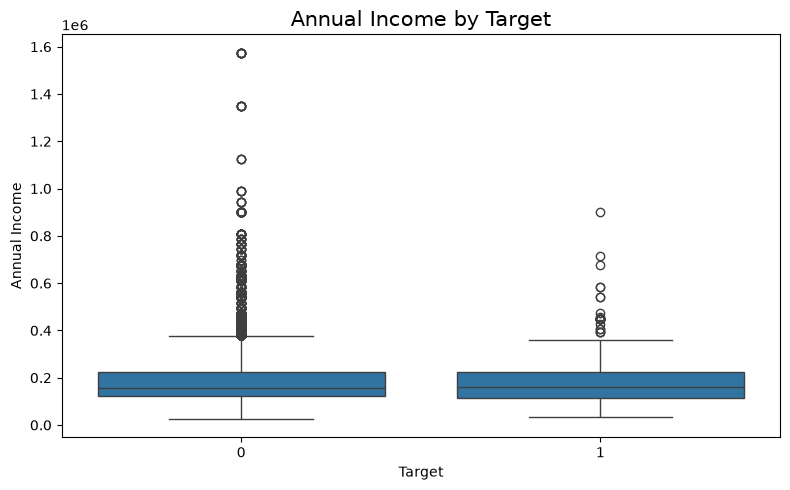

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="TARGET",
    y="AMT_INCOME_TOTAL"
)

plt.title("Annual Income by Target", fontsize=15)
plt.xlabel("Target")
plt.ylabel("Annual Income")

plt.tight_layout()

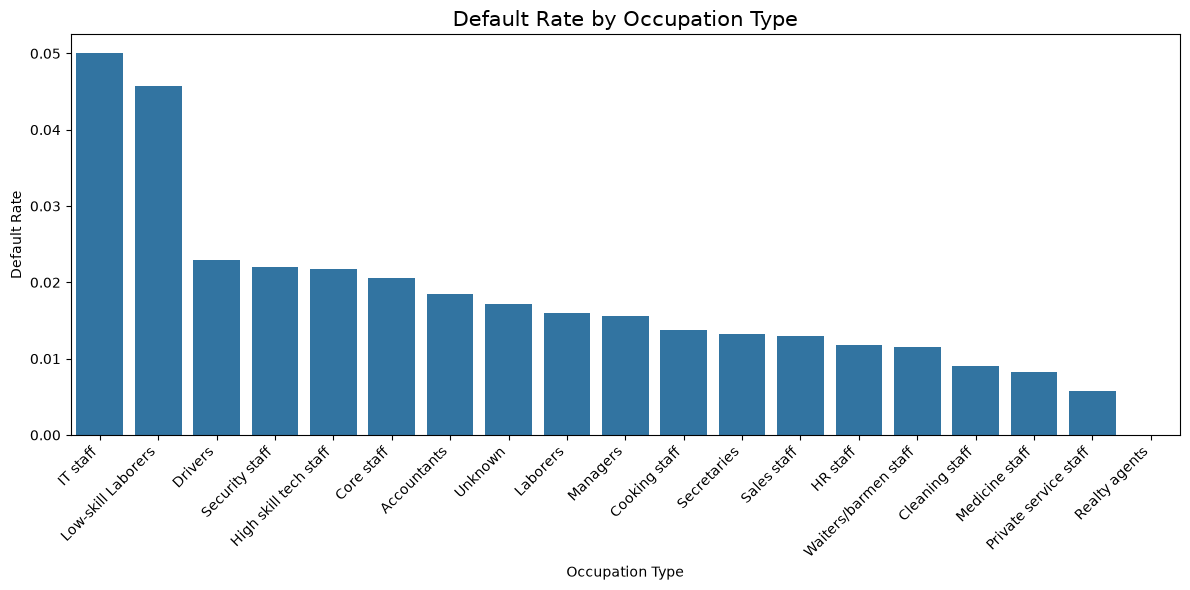

In [55]:
# Calculate default rate for each occupation
occupation_default = (
    df_clean
    .groupby("OCCUPATION_TYPE")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=occupation_default.index,
    y=occupation_default.values
)

plt.title("Default Rate by Occupation Type", fontsize=15)
plt.xlabel("Occupation Type")
plt.ylabel("Default Rate")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Widow'),
  Text(1, 0, 'Single / not married'),
  Text(2, 0, 'Married'),
  Text(3, 0, 'Civil marriage'),
  Text(4, 0, 'Separated')])

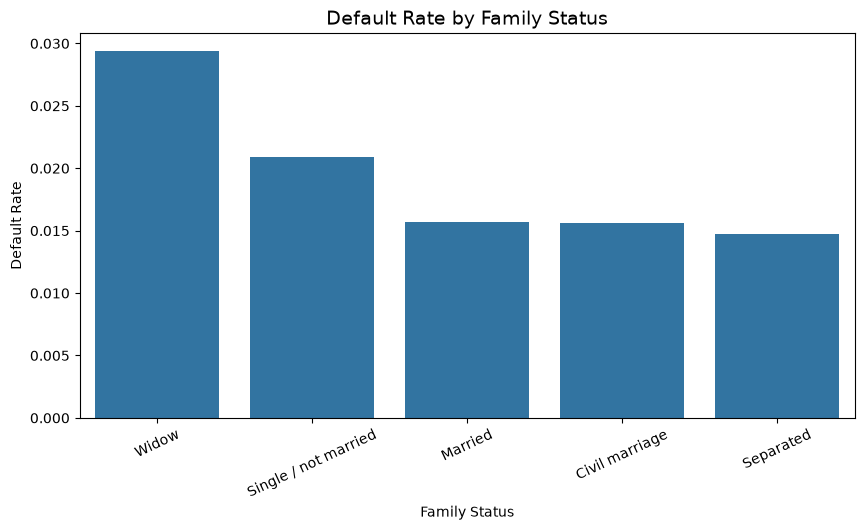

In [56]:
# ==========================================
# Family Status vs Default Rate Analysis
# ==========================================

family_default = (
    df.groupby("NAME_FAMILY_STATUS")["TARGET"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=family_default.index,
    y=family_default.values
)

plt.title("Default Rate by Family Status", fontsize=14)
plt.xlabel("Family Status")
plt.ylabel("Default Rate")
plt.xticks(rotation=25)

C:\Users\piyus\AppData\Local\Temp\ipykernel_19732\1454591273.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


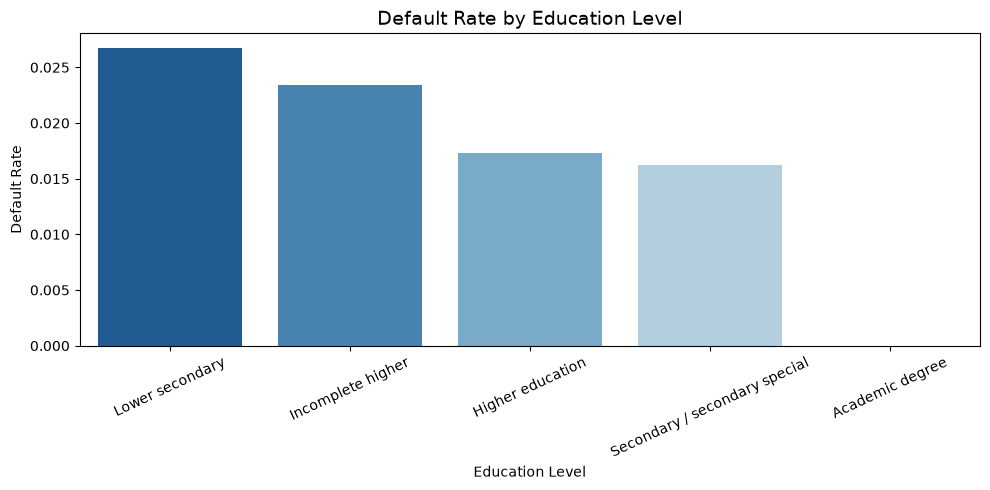

In [57]:
# ======================================
# Default Rate by Education Level
# ======================================

education_default = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=education_default.index,
    y=education_default.values,
    palette="Blues_r"
)

plt.title("Default Rate by Education Level", fontsize=14)
plt.xlabel("Education Level")
plt.ylabel("Default Rate")

plt.xticks(rotation=25)

plt.tight_layout()

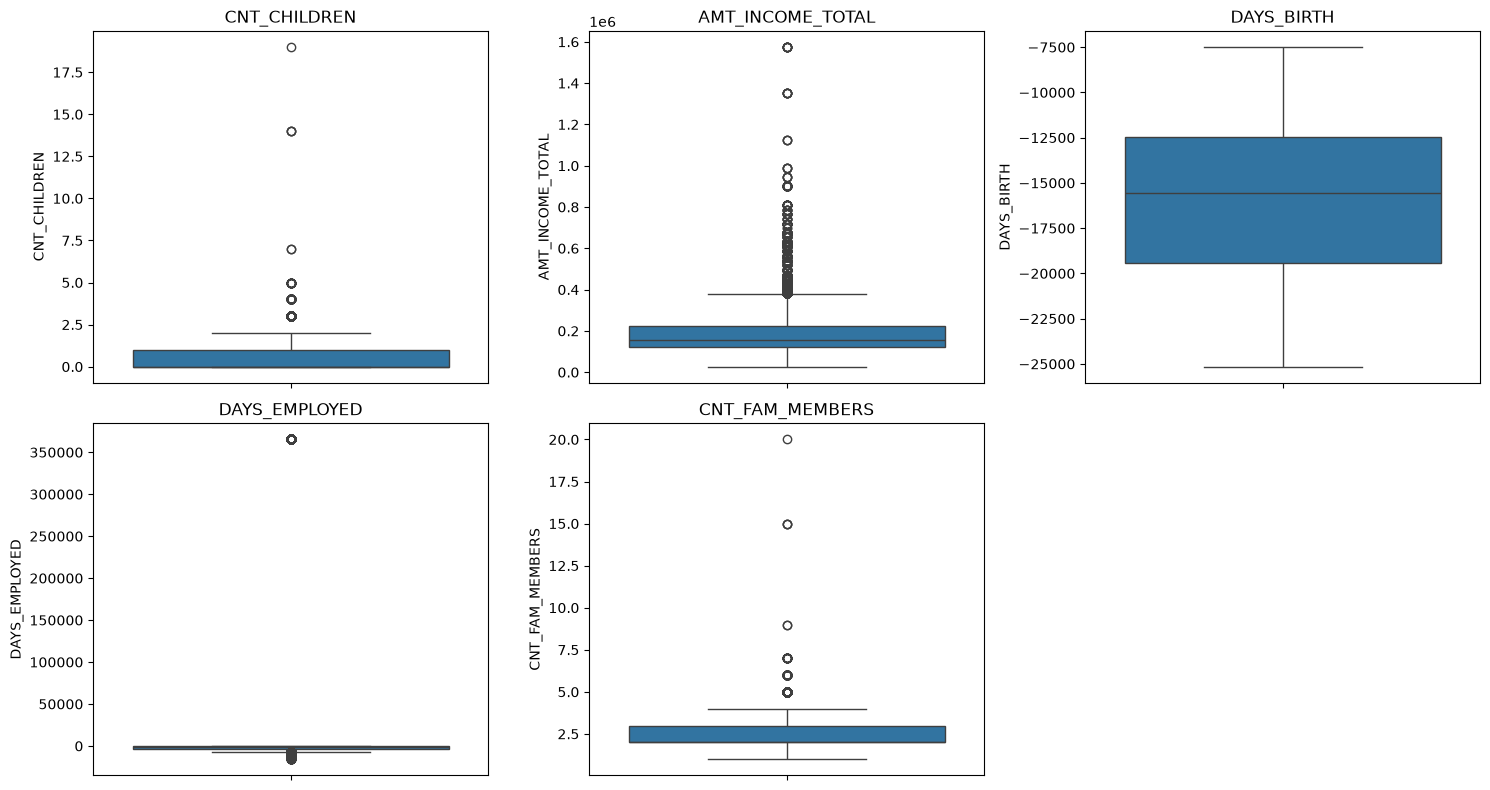

In [58]:
numerical_cols = [
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_FAM_MEMBERS'
]

# Display Boxplots
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()

In [59]:
# Columns to apply IQR Capping
outlier_cols = [
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'CNT_FAM_MEMBERS'
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers have been treated using IQR Capping.")

Outliers have been treated using IQR Capping.


In [60]:
# =============================================
# Handling Special Values in DAYS_EMPLOYED
# =============================================

# Replace the special value with NaN
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

print("Number of missing values in DAYS_EMPLOYED:")
print(df['DAYS_EMPLOYED'].isnull().sum())

Number of missing values in DAYS_EMPLOYED:
6135


In [62]:
# Fill missing values in OCCUPATION_TYPE with 'Unknown'
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

# Fill missing values in DAYS_EMPLOYED with the median
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(df['DAYS_EMPLOYED'].median())

# Verify that no missing values remain
print(df.isnull().sum()[df.isnull().sum() > 0])

# Create Age feature (years)
df['AGE'] = (-df['DAYS_BIRTH'] / 365).astype(int)

# Create Employment Years feature
df['EMPLOYMENT_YEARS'] = (-df['DAYS_EMPLOYED'] / 365).clip(lower=0)

# Drop the original columns
df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

print(df[['AGE', 'EMPLOYMENT_YEARS']].head())

Series([], dtype: int64)
   AGE  EMPLOYMENT_YEARS
0   32         12.443836
1   32         12.443836
2   58          3.106849
3   52          8.358904
4   52          8.358904


In [63]:
df['INCOME_PER_FAMILY_MEMBER'] = (
    df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
)

# Has Children
df['HAS_CHILDREN'] = (df['CNT_CHILDREN'] > 0).astype(int)

# Is Working
df['IS_WORKING'] = (df['EMPLOYMENT_YEARS'] > 0).astype(int)

# Display new features
df[['INCOME_PER_FAMILY_MEMBER',
    'HAS_CHILDREN',
    'IS_WORKING']].head()

,INCOME_PER_FAMILY_MEMBER,HAS_CHILDREN,IS_WORKING
0,190125.0,0,1
1,190125.0,0,1
2,56250.0,0,1
3,270000.0,0,1
4,270000.0,0,1


In [64]:
# Display categorical columns

categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Number of Categorical Features: {len(categorical_cols)}\n')

for col in categorical_cols:
    print(col)

Number of Categorical Features: 8

CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
OCCUPATION_TYPE


C:\Users\piyus\AppData\Local\Temp\ipykernel_19732\304075394.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [65]:
# ===============================================
# One-Hot Encoding for Categorical Features
# ===============================================

# Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Dataset Shape After Encoding:", df.shape)

df.head()

Dataset Shape After Encoding: (36457, 52)


,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,TARGET,AGE,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,5008804,0.0,380250.0,1,1,0,0,2.0,0,32,...,0,0,0,0,0,0,0,0,1,0
1,5008805,0.0,380250.0,1,1,0,0,2.0,0,32,...,0,0,0,0,0,0,0,0,1,0
2,5008806,0.0,112500.0,1,0,0,0,2.0,0,58,...,0,0,0,0,0,0,0,1,0,0
3,5008808,0.0,270000.0,1,0,1,1,1.0,0,52,...,0,0,0,0,0,1,0,0,0,0
4,5008809,0.0,270000.0,1,0,1,1,1.0,0,52,...,0,0,0,0,0,1,0,0,0,0


In [66]:
# ==========================================
# Feature Scaling using StandardScaler
# ==========================================

from sklearn.preprocessing import StandardScaler

# Copy dataset
df_scaled = df.copy()

# Numerical columns (excluding TARGET)
numerical_cols = df_scaled.select_dtypes(include=['int64', 'float64']).columns.drop('TARGET')

# Apply Standard Scaling
scaler = StandardScaler()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print(df_scaled[numerical_cols].head())

         ID  CNT_CHILDREN  AMT_INCOME_TOTAL  FLAG_MOBIL  FLAG_WORK_PHONE  \
0 -1.657876     -0.608334          2.448877         0.0         1.853127   
1 -1.657852     -0.608334          2.448877         0.0         1.853127   
2 -1.657828     -0.608334         -0.849261         0.0        -0.539628   
3 -1.657780     -0.608334          1.090820         0.0        -0.539628   
4 -1.657756     -0.608334          1.090820         0.0        -0.539628   

   FLAG_PHONE  FLAG_EMAIL  CNT_FAM_MEMBERS       AGE  EMPLOYMENT_YEARS  ...  \
0   -0.646578   -0.313952        -0.216030 -0.978287          0.927312  ...   
1   -0.646578   -0.313952        -0.216030 -0.978287          0.927312  ...   
2   -0.646578   -0.313952        -0.216030  1.280568         -0.647734  ...   
3    1.546603    3.185203        -1.366453  0.759294          0.238230  ...   
4    1.546603    3.185203        -1.366453  0.759294          0.238230  ...   

   OCCUPATION_TYPE_Low-skill Laborers  OCCUPATION_TYPE_Managers  \
0

In [67]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df_scaled.drop(columns=['TARGET'])
y = df_scaled['TARGET']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print("\nTarget Distribution in Training Set")
print(y_train.value_counts(normalize=True))

print("\nTarget Distribution in Testing Set")
print(y_test.value_counts(normalize=True))

Training Set : (29165, 51)
Testing Set  : (7292, 51)

Target Distribution in Training Set
TARGET
0    0.983096
1    0.016904
Name: proportion, dtype: float64

Target Distribution in Testing Set
TARGET
0    0.983132
1    0.016868
Name: proportion, dtype: float64


In [68]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model.
# random_state=42 makes the model's random operations reproducible.
# class_weight="balanced" gives more importance to the minority class,
# which is useful when the target classes are imbalanced.
# max_iter=1000 allows the optimizer up to 1000 iterations to find
# the best model parameters and helps prevent convergence warnings.
log_reg = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

# Train the model using the training features (X_train) and their
# corresponding target labels (y_train). During training, Logistic
# Regression learns the coefficients that are used to estimate the
# probability of each class.
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Generate the final class predictions for the test data.
# predict() uses the learned model to assign each sample to class 0 or 1.
y_pred = log_reg.predict(X_test)

# Get the probability of each sample belonging to class 1.
# predict_proba() returns probabilities for both classes, and [:, 1]
# selects the probability corresponding to the positive class (1).
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Print a formatted heading to separate the model evaluation results.
print("=" * 50)
print("Logistic Regression Performance")
print("=" * 50)

# Accuracy measures the overall percentage of predictions that are correct.
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")

# Precision measures how many customers predicted as class 1
# actually belong to class 1.
print(f"Precision: {precision_score(y_test, y_pred):.4f}")

# Recall measures how many actual class 1 customers were correctly identified.
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")

# F1 Score combines precision and recall into a single metric.
# It is useful when the classes are imbalanced because it considers both
# false positives and false negatives.
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

# ROC-AUC evaluates how well the model separates class 0 from class 1
# across different classification thresholds.
# It uses probabilities rather than the final 0/1 predictions.
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

# Display precision, recall, F1-score, and sample counts for each class.
# This gives a more detailed view of how the model performs on both classes.
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Logistic Regression Performance
Accuracy : 0.5876
Precision: 0.0209
Recall   : 0.5122
F1 Score : 0.0402
ROC-AUC  : 0.5576

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.59      0.74      7169
           1       0.02      0.51      0.04       123

    accuracy                           0.59      7292
   macro avg       0.50      0.55      0.39      7292
weighted avg       0.97      0.59      0.73      7292



In [70]:
from sklearn.metrics import confusion_matrix

# Compare the actual classes with the model's predicted classes.
# The matrix shows how many predictions fall into each
# true-positive, true-negative, false-positive, and false-negative category.
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4222 2947]
 [  60   63]]


In [73]:
# ============================================================
# Apply SMOTE to Balance the Training Dataset
# ============================================================

from imblearn.over_sampling import SMOTE

# Create a SMOTE object.
# SMOTE generates new synthetic samples for the minority class
# by creating points between existing minority-class observations.
# This helps reduce the class imbalance without simply duplicating
# the same minority samples.
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data.
# fit_resample() learns the minority-class structure from X_train
# and creates additional samples, returning the balanced features
# and their corresponding target labels.
#
# The test set is intentionally left unchanged so that it still
# represents the original real-world class distribution.
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("=" * 50)
print("Class Distribution Before SMOTE")
print("=" * 50)

# Count how many samples belong to each class before oversampling.
print(y_train.value_counts())

print("\n" + "=" * 50)
print("Class Distribution After SMOTE")
print("=" * 50)

# Count the classes again after SMOTE to verify that the
# minority class has been increased to match the majority class.
print(y_train_smote.value_counts())

Class Distribution Before SMOTE
TARGET
0    28672
1      493
Name: count, dtype: int64

Class Distribution After SMOTE
TARGET
0    28672
1    28672
Name: count, dtype: int64


In [78]:
# ============================================================
# Random Forest after SMOTE
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Create a Random Forest containing 200 decision trees.
# Each tree learns from the balanced SMOTE training data, and
# their combined predictions are used to make the final decision.
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the forest using the synthetic minority samples created by SMOTE.
# The model learns patterns from X_train_smote and their corresponding labels.
rf_smote.fit(X_train_smote, y_train_smote)

# Generate the predicted class (0 or 1) for each untouched test sample.
# The forest combines the predictions from its 200 trees to select the final class.
y_pred_smote = rf_smote.predict(X_test)

# Get the probability of each test sample belonging to class 1.
# [:, 1] selects the class-1 probability, which is needed for ROC-AUC.
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

# ============================================================
# Evaluation
# ============================================================

print("=" * 60)
print("Random Forest + SMOTE Performance")
print("=" * 60)

# Accuracy measures the overall percentage of correct predictions.
print(f"Accuracy : {accuracy_score(y_test, y_pred_smote):.4f}")

# Precision measures how many customers predicted as class 1
# were actually class 1.
print(f"Precision: {precision_score(y_test, y_pred_smote):.4f}")

# Recall measures how many of the actual class-1 customers
# were successfully detected by the model.
print(f"Recall   : {recall_score(y_test, y_pred_smote):.4f}")

# F1 combines precision and recall using their harmonic mean,
# so it becomes low when either precision or recall is low.
print(f"F1 Score : {f1_score(y_test, y_pred_smote):.4f}")

# ROC-AUC evaluates how well the model separates class 0 from class 1
# across different probability thresholds rather than using only 0.5.
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_smote):.4f}")

print("\nClassification Report\n")

# Show precision, recall, F1-score, and number of samples for each class.
# This is especially important here because the original dataset is highly imbalanced.
print(classification_report(y_test, y_pred_smote))

Random Forest + SMOTE Performance
Accuracy : 0.9765
Precision: 0.2391
Recall   : 0.1789
F1 Score : 0.2047
ROC-AUC  : 0.7957

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.24      0.18      0.20       123

    accuracy                           0.98      7292
   macro avg       0.61      0.58      0.60      7292
weighted avg       0.97      0.98      0.97      7292



In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Create a Random Forest consisting of 200 decision trees.
# Each tree learns different patterns from the training data, and the
# forest combines their predictions to make the final classification.
#
# class_weight="balanced" gives more importance to the minority class,
# which is useful because class 1 is much less frequent than class 0.
# n_jobs=-1 allows sklearn to use all available CPU cores during training.
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train all 200 trees using the training features and target labels.
# The forest learns decision rules that distinguish class 0 from class 1.
rf_model.fit(X_train, y_train)

# Predict the class (0 or 1) for each sample in the test set.
# predict() uses the combined decision of all trees to choose the final class.
y_pred_rf = rf_model.predict(X_test)

# Get the probability of each test sample belonging to class 1.
# [:, 1] selects the probability for the positive class, which is
# needed for metrics such as ROC-AUC.
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Print a formatted heading before displaying the evaluation metrics.
print("=" * 60)
print("Random Forest Performance")
print("=" * 60)

# Calculate the percentage of all test predictions that are correct.
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")

# Measure how many samples predicted as class 1 are actually class 1.
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")

# Measure how many of the actual class 1 samples were successfully detected.
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")

# Combine precision and recall into a single score.
# A high F1 score requires both precision and recall to be reasonably high.
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")

# Measure how well the model separates class 0 from class 1 across
# different probability thresholds.
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

# Show precision, recall, F1-score, and the number of actual samples
# for each class to get a detailed view of model performance.
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
Accuracy : 0.9738
Precision: 0.2463
Recall   : 0.2683
F1 Score : 0.2568
ROC-AUC  : 0.8263

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.25      0.27      0.26       123

    accuracy                           0.97      7292
   macro avg       0.62      0.63      0.62      7292
weighted avg       0.97      0.97      0.97      7292



In [80]:
# ============================================================
# XGBoost Classifier
# ============================================================

# Install XGBoost
# Run this only once if XGBoost is not already installed.
# The -q flag keeps the installation output quiet.
!pip -q install xgboost


# Import XGBoost's classification algorithm
from xgboost import XGBClassifier

# Import evaluation metrics from scikit-learn
from sklearn.metrics import (
    accuracy_score,        # Percentage of correct predictions
    precision_score,       # How many predicted positives were actually positive
    recall_score,          # How many actual positives were correctly detected
    f1_score,              # Harmonic mean of precision and recall
    roc_auc_score,         # Measures how well the model separates the classes
    classification_report # Gives precision, recall, F1-score and support
)


# ============================================================
# Build the XGBoost Model
# ============================================================

# Create an XGBoost classifier with the selected hyperparameters
xgb_model = XGBClassifier(

    # Number of boosting rounds / trees
    # More trees can improve learning, but may increase training time
    n_estimators=300,

    # Controls how much each new tree contributes to the final model
    # Smaller values make learning slower but can improve generalization
    learning_rate=0.05,

    # Maximum depth allowed for each decision tree
    # Higher depth allows the model to learn more complex patterns
    max_depth=6,

    # Ensures that the results are reproducible
    random_state=42,

    # Binary classification with logistic output
    # The model will produce probabilities between 0 and 1
    objective='binary:logistic',

    # Loss function used to evaluate the model during training
    # logloss is commonly used for binary classification
    eval_metric='logloss'
)


# ============================================================
# Train the Model
# ============================================================

# Train XGBoost using the SMOTE-balanced training dataset
#
# X_train_smote -> feature values after applying SMOTE
# y_train_smote -> corresponding target values after applying SMOTE
#
# IMPORTANT:
# We train on the SMOTE data, but evaluate on the original X_test.
# The test set should NOT be SMOTE-balanced because it should represent
# real-world data distribution.
xgb_model.fit(X_train_smote, y_train_smote)


# ============================================================
# Make Predictions
# ============================================================

# Predict the final class labels for the test data
# Output will usually be 0 or 1 for binary classification
y_pred_xgb = xgb_model.predict(X_test)


# Get the probability of belonging to class 1
#
# predict_proba() returns probabilities for both classes:
# [probability_of_class_0, probability_of_class_1]
#
# [:, 1] selects the probability of class 1.
#
# These probabilities are needed for metrics such as ROC-AUC.
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


# ============================================================
# Evaluate the Model
# ============================================================

# Print a separator for better readability
print("=" * 60)

# Print the model name
print("XGBoost Performance")

# Print another separator
print("=" * 60)


# Calculate and print Accuracy
# .4f means display the result with 4 decimal places
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")


# Calculate and print Precision
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")


# Calculate and print Recall
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")


# Calculate and print F1 Score
print(f"F1 Score : {f1_score(y_test, y_pred_xgb):.4f}")


# Calculate and print ROC-AUC
#
# Notice that we use y_prob_xgb instead of y_pred_xgb.
# ROC-AUC requires prediction probabilities/scores rather than
# only the final 0/1 predictions.
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")


# ============================================================
# Detailed Classification Report
# ============================================================

# Print a heading
print("\nClassification Report\n")

# Display precision, recall, F1-score and support
# separately for each class.
print(classification_report(y_test, y_pred_xgb))

XGBoost Performance
Accuracy : 0.9768
Precision: 0.2386
Recall   : 0.1707
F1 Score : 0.1991
ROC-AUC  : 0.6531

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.24      0.17      0.20       123

    accuracy                           0.98      7292
   macro avg       0.61      0.58      0.59      7292
weighted avg       0.97      0.98      0.97      7292



In [82]:
# ======================================================
# Model Comparison
# ======================================================

# Import pandas for creating and displaying the comparison table
import pandas as pd


# Create a DataFrame containing the evaluation results
# of all the models
comparison = pd.DataFrame({

    # Names of the models being compared
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest + SMOTE",
        "XGBoost + SMOTE"
    ],

    # ------------------------------------------------------
    # Accuracy
    # ------------------------------------------------------
    # Compare the accuracy of each model on the same test set
    "Accuracy": [
        accuracy_score(y_test, y_pred),          # Logistic Regression
        accuracy_score(y_test, y_pred_rf),       # Random Forest
        accuracy_score(y_test, y_pred_smote),    # Random Forest + SMOTE
        accuracy_score(y_test, y_pred_xgb)       # XGBoost + SMOTE
    ],

    # ------------------------------------------------------
    # Precision
    # ------------------------------------------------------
    # Measures how many predicted positive samples
    # were actually positive
    "Precision": [
        precision_score(y_test, y_pred),          # Logistic Regression
        precision_score(y_test, y_pred_rf),       # Random Forest
        precision_score(y_test, y_pred_smote),    # Random Forest + SMOTE
        precision_score(y_test, y_pred_xgb)       # XGBoost + SMOTE
    ],

    # ------------------------------------------------------
    # Recall
    # ------------------------------------------------------
    # Measures how many actual positive samples
    # were correctly detected
    "Recall": [
        recall_score(y_test, y_pred),          # Logistic Regression
        recall_score(y_test, y_pred_rf),       # Random Forest
        recall_score(y_test, y_pred_smote),    # Random Forest + SMOTE
        recall_score(y_test, y_pred_xgb)       # XGBoost + SMOTE
    ],

    # ------------------------------------------------------
    # F1 Score
    # ------------------------------------------------------
    # Combines precision and recall into a single metric
    "F1 Score": [
        f1_score(y_test, y_pred),          # Logistic Regression
        f1_score(y_test, y_pred_rf),       # Random Forest
        f1_score(y_test, y_pred_smote),    # Random Forest + SMOTE
        f1_score(y_test, y_pred_xgb)       # XGBoost + SMOTE
    ],

    # ------------------------------------------------------
    # ROC-AUC
    # ------------------------------------------------------
    # Measures how well the model separates Class 0
    # from Class 1 using prediction probabilities
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),          # Logistic Regression
        roc_auc_score(y_test, y_prob_rf),       # Random Forest
        roc_auc_score(y_test, y_prob_smote),    # Random Forest + SMOTE
        roc_auc_score(y_test, y_prob_xgb)       # XGBoost + SMOTE
    ]
})


# Round all numerical values to 4 decimal places
# Example: 0.976823 → 0.9768
comparison = comparison.round(4)


# Display the final comparison table
display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5876,0.0209,0.5122,0.0402,0.5576
1,Random Forest,0.9738,0.2463,0.2683,0.2568,0.8263
2,Random Forest + SMOTE,0.9765,0.2391,0.1789,0.2047,0.7957
3,XGBoost + SMOTE,0.9768,0.2386,0.1707,0.1991,0.6531


Text(0.5, 1.0, 'Confusion Matrix - Random Forest + SMOTE')

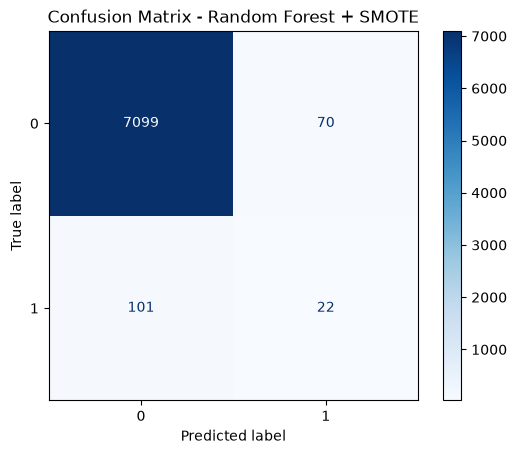

In [83]:
# ======================================================
# Confusion Matrix
# ======================================================

# Import ConfusionMatrixDisplay to create the confusion matrix
# directly from the true labels and predicted labels
from sklearn.metrics import ConfusionMatrixDisplay

# Import matplotlib for displaying and customizing the plot
import matplotlib.pyplot as plt


# ======================================================
# Plot Confusion Matrix
# ======================================================

# Create the confusion matrix using:
#
# y_test      → actual/true class labels
# y_pred_smote → predictions made by Random Forest + SMOTE
#
# The matrix shows:
# True Negatives  (TN)
# False Positives (FP)
# False Negatives (FN)
# True Positives  (TP)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote,

    # Use a blue color gradient for the matrix
    cmap="Blues",

    # Display the values as integers
    # Example: 7160 instead of 7160.0
    values_format="d"
)


# Add a title above the confusion matrix
plt.title("Confusion Matrix - Random Forest + SMOTE")

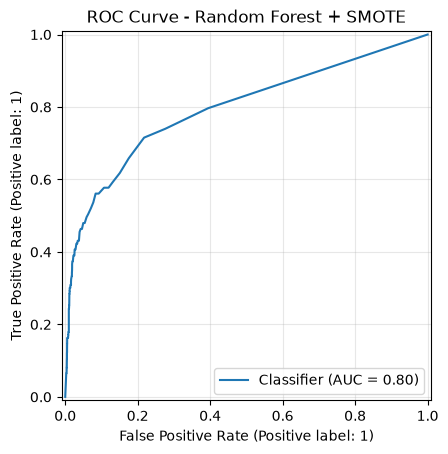

In [84]:
# ======================================================
# ROC Curve
# ======================================================

# Import RocCurveDisplay to plot the ROC curve
# directly from the true labels and predicted probabilities
from sklearn.metrics import RocCurveDisplay

# Import matplotlib for customizing the graph
import matplotlib.pyplot as plt


# ======================================================
# Plot ROC Curve
# ======================================================

# Create the ROC curve using:
#
# y_test       → actual class labels
# y_prob_smote → predicted probability of Class 1
#
# IMPORTANT:
# We use predicted probabilities here, NOT predicted labels.
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_smote
)


# Add a title to the graph
plt.title("ROC Curve - Random Forest + SMOTE")


# Add a light grid to make the graph easier to read
# alpha controls the transparency of the grid
plt.grid(alpha=0.3)

,Feature,Importance
0,ID,0.096773
8,AGE,0.073451
2,AMT_INCOME_TOTAL,0.071068
10,INCOME_PER_FAMILY_MEMBER,0.067356
15,FLAG_OWN_REALTY_Y,0.063611
9,EMPLOYMENT_YEARS,0.061488
14,FLAG_OWN_CAR_Y,0.061198
13,CODE_GENDER_M,0.053799
19,NAME_INCOME_TYPE_Working,0.051338
5,FLAG_PHONE,0.049884


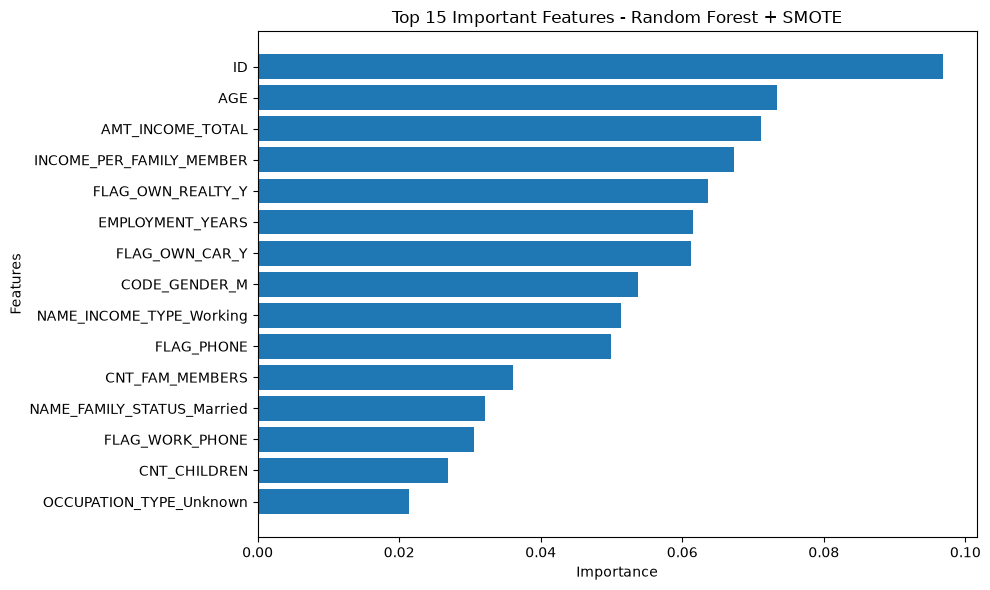

In [85]:
# ======================================================
# Feature Importance
# ======================================================

# Import pandas for creating and working with the
# feature importance DataFrame
import pandas as pd

# Import matplotlib for plotting the feature importance
import matplotlib.pyplot as plt


# ======================================================
# Create Feature Importance DataFrame
# ======================================================

# Random Forest calculates an importance score for every feature.
#
# X_train.columns
#     → contains the names of all features used during training
#
# rf_smote.feature_importances_
#     → contains the importance score assigned to each feature
#
# We combine both into a DataFrame so that we can easily
# see which features are contributing the most to the model.
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_smote.feature_importances_
})


# ======================================================
# Sort Features
# ======================================================

# Sort the features from highest importance to lowest importance.
#
# This makes it easier to identify the most influential
# features when we display the results.
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


# ======================================================
# Display Top 15 Features
# ======================================================

# Display only the 15 features with the highest
# importance scores.
display(feature_importance.head(15))


# ======================================================
# Plot Feature Importance
# ======================================================

# Create a figure with a width of 10 inches and
# a height of 6 inches.
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart for the top 15 features.
#
# head(15)
#     → selects the 15 most important features
#
# [::-1]
#     → reverses their order
#
# Reversing is useful for a horizontal bar chart because
# the most important feature will appear at the top.
plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)

# Label the x-axis.
plt.xlabel("Importance")

# Label the y-axis.
plt.ylabel("Features")

# Add a title describing the model used.
plt.title("Top 15 Important Features - Random Forest + SMOTE")

# Automatically adjust spacing so that labels and
# the title fit properly inside the figure.
plt.tight_layout()

# Display the plot.
plt.show()

In [86]:
# ======================================================
# Save Best Model
# ======================================================

import joblib

# Save Random Forest Model
joblib.dump(rf_smote, "credit_default_random_forest.pkl")

# Save Standard Scaler
joblib.dump(scaler, "standard_scaler.pkl")

print("Model and Scaler saved successfully.")

Model and Scaler saved successfully.


In [87]:
# ======================================================
# Final Model Testing
# ======================================================

from sklearn.metrics import accuracy_score

# Predict on the test set
test_predictions = rf_smote.predict(X_test)

# Calculate Accuracy
test_accuracy = accuracy_score(y_test, test_predictions)

print("=" * 55)
print("Final Model Test Results")
print("=" * 55)

print(f"Test Samples       : {len(y_test)}")
print(f"Correct Predictions: {(test_predictions == y_test).sum()}")
print(f"Wrong Predictions  : {(test_predictions != y_test).sum()}")
print(f"Test Accuracy      : {test_accuracy:.4f}")

print("=" * 55)
print("The model was successfully evaluated on unseen test data.")
print("=" * 55)

Final Model Test Results
Test Samples       : 7292
Correct Predictions: 7121
Wrong Predictions  : 171
Test Accuracy      : 0.9765
The model was successfully evaluated on unseen test data.
